# Machine Learning Classification Model

In [72]:
???

Object `?` not found.


## Load the data

In [73]:
import pandas as pd

df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx', parse_dates=['Date'], index_col=0)
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,61.009998,61.580002,60.840000,61.299999,21220800,1.549141,UP
2016-12-09,61.970001,61.990002,61.130001,61.180000,27349400,0.321694,UP
2016-12-12,62.169998,62.299999,61.720001,61.820000,20198100,1.286125,UP
2016-12-13,62.980000,63.419998,62.240002,62.500000,35718900,-0.478620,DOWN
2016-12-14,62.680000,63.450001,62.529999,63.000000,30352700,-0.159793,DOWN
...,...,...,...,...,...,...,...
2026-05-14,409.429993,411.839996,400.880005,404.480011,27077500,2.960282,UP
2026-05-15,421.920013,428.170013,412.910004,414.269989,50771200,0.382489,UP
2026-05-18,423.540009,425.119995,415.609985,416.619995,32564100,-1.466148,DOWN


## Machine Learning Model

### Separate the data

1. Target: which variable do you want to predict?
2. Explanatory: which variables will you use to calculate the prediction?

In [74]:
target= df.change_tomorrow_direction

In [75]:
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,61.009998,61.580002,60.840000,61.299999,21220800,1.549141,UP
2016-12-09,61.970001,61.990002,61.130001,61.180000,27349400,0.321694,UP
2016-12-12,62.169998,62.299999,61.720001,61.820000,20198100,1.286125,UP
2016-12-13,62.980000,63.419998,62.240002,62.500000,35718900,-0.478620,DOWN
2016-12-14,62.680000,63.450001,62.529999,63.000000,30352700,-0.159793,DOWN
...,...,...,...,...,...,...,...
2026-05-14,409.429993,411.839996,400.880005,404.480011,27077500,2.960282,UP
2026-05-15,421.920013,428.170013,412.910004,414.269989,50771200,0.382489,UP
2026-05-18,423.540009,425.119995,415.609985,416.619995,32564100,-1.466148,DOWN


In [76]:
explanatory= df.drop(columns=['change_tomorrow','change_tomorrow_direction'])

### Compute the model

The following Python code will compute the numbers of the mathematical equation that we will use to calculate if the ticker goes UP or DOWN.

In [77]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [78]:
from sklearn.tree import DecisionTreeClassifier

In [79]:
model_dt= DecisionTreeClassifier(max_depth=15)

In [80]:
model_dt.fit(X=explanatory, y=target)

DecisionTreeClassifier(max_depth=15)

### Visualize the model

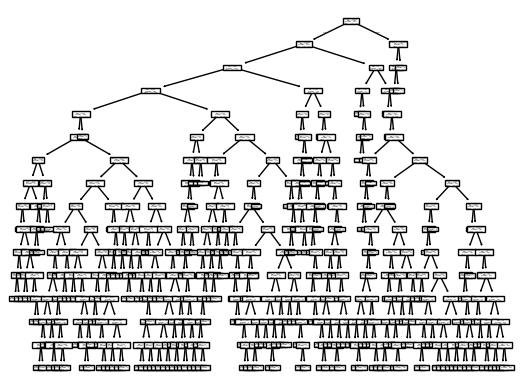

In [81]:
from sklearn.tree import plot_tree

plot_tree(decision_tree=model_dt, feature_names=model_dt.feature_names_in_);

### Calculate the predictions

In [82]:
y_pred= model_dt.predict(X=explanatory)

In [83]:
df_predictions = df[['change_tomorrow_direction']].copy()
df_predictions['prediction'] = y_pred
df_predictions

,change_tomorrow_direction,prediction
Date,,
2016-12-08,UP,UP
2016-12-09,UP,UP
2016-12-12,UP,UP
2016-12-13,DOWN,DOWN
2016-12-14,DOWN,DOWN
...,...,...
2026-05-14,UP,DOWN
2026-05-15,UP,DOWN
2026-05-18,DOWN,DOWN


### Evaluate the model: compare predictions with the reality

In [84]:
comp= df_predictions.change_tomorrow_direction == df_predictions.prediction

In [85]:
comp.sum()

np.int64(1716)

In [86]:
len(comp)

2374

In [87]:
comp.sum()/len(comp)

np.float64(0.7228306655433867)

In [88]:
model_dt.score(X=explanatory, y=target)

0.7228306655433867

## Save the model into a file

- We'll write the numbers of the Decision Tree's mathematical equation into a file.

In [92]:
import os

In [ ]:
os.makedirs('models')

In [90]:
model_dt

DecisionTreeClassifier(max_depth=15)

In [91]:
import pickle

In [93]:
with open('models/model_dt_classification.pkl', 'wb') as f:
    pickle.dump(model_dt, f)